# 01 · Tutelas — Exploración Inicial
**Objetivo:** Entender la estructura del dataset antes de analizar. Aquí no se construye ningún indicador ni se saca ninguna conclusión final — solo observamos, contamos y nos preguntamos.

**Datos:** `data/tutelas - Detalle1.csv`

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../data/tutelas - Detalle1.csv'
REFERENCE_DATE = pd.Timestamp('2026-05-11')  # fecha de análisis

## 1. Carga y estructura general

In [11]:
df = pd.read_csv(DATA_PATH, encoding='utf-8', sep=None, engine='python')

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()
print('Columnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

Filas:    12,952
Columnas: 47

Columnas disponibles:
   1. Nombre del fichero
   2. Estado del ciclo de vida
   3. Fecha de creación
   4. Autor
   5. Clasificación TTL
   6. Compañía
   7. Fecha y hora notificación tutela
   8. Horas otorgadas
   9. Fecha Vencimiento Admision
  10. Regional T
  11. Radicado juzgado
  12. Juzgado
  13. Abogado asignado tutela
  14. Medida provisional
  15. Tiene Fallo 2da instancia
  16. Usuario área técnica EPS SALUD
  17. Usuario área técnica ARL SALUD
  18. Fecha Reasignacion Concepto Salud
  19. Fecha_Asignacion_Concepto
  20. Fecha Limite Concepto Admisión
  21. Fecha finalización concepto
  22. Area causal
  23. Area causal_Salud EPS
  24. Motivo Causal Juridico
  25. Odontologia
  26. Tutela evitable
  27. Area causal_2
  28. Area causal_3
  29. Area causal_4
  30. PBS/NO PBS
  31. Nombres Beneficiarios
  32. Accionante
  33. Fecha y hora de Contestación
  34. Fecha y hora notificación 1ra Instancia
  35. Horas para cumplimiento 1ra Instancia
  

In [12]:
# Tipos de dato y primeros valores por columna
df.dtypes.to_frame('dtype').assign(sample=df.iloc[0]).head(47)

,dtype,sample
Nombre del fichero,object,EXP-T-26-000000000 - 2025-0579 - 1011402402
Estado del ciclo de vida,object,Cumplimiento Fallo 1 Terminado
Fecha de creación,object,2026-01-02 07:33:30
Autor,object,Administrator
Clasificación TTL,object,2. Medida Provisional
Compañía,object,EPS
Fecha y hora notificación tutela,object,2025-12-31 16:45:00
Horas otorgadas,float64,48.0
Fecha Vencimiento Admision,object,2026-01-05 17:00:00
Regional T,object,ANTIOQUIA


## 1b. Diagnóstico de tipos — ¿qué columnas tienen el tipo incorrecto?

In [13]:

# Pandas lee como float64 las columnas que son 100% NaN en la muestra inicial.
# Identificamos las columnas problemáticas separándolas por categoría.

# --- Columnas que deberían ser fechas (datetime) ---
expected_dates = [
    'Fecha de creación',
    'Fecha y hora notificación tutela',
    'Fecha Vencimiento Admision',
    'Fecha Reasignacion Concepto Salud',
    'Fecha_Asignacion_Concepto',
    'Fecha Limite Concepto Admisión',
    'Fecha finalización concepto',
    'Fecha y hora de Contestación',
    'Fecha y hora notificación 1ra Instancia',
    'Fecha vencimiento fallo 1ra Instancia',
    'Fecha y hora Notificación 2da Instancia',
    'Fecha vencimiento fallo 2da Instancia',
    'Fecha y hora fallo Corte Constitucional',
    'Fecha vencimiento fallo corte',
]

# --- Columnas que deberían ser categóricas (object) pero pandas las leyó como float ---
misread_as_float = [
    'Motivo Causal Juridico',     # debería ser texto categórico
    'Tutela evitable',             # debería ser Sí/No
    'PBS/NO PBS',                  # debería ser categórico
    'Prestación sucesiva 1ra instancia',  # debería ser categórico
]

# --- Columnas numéricas correctas ---
correct_numeric = [
    'Horas otorgadas',
    'Horas para cumplimiento 1ra Instancia',
    'Horas para cumplimiento 2da Instancia',
]

print('Columnas leídas como object (strings) que SON fechas:')
for c in expected_dates:
    actual = df[c].dtype
    status = '✓ ya en object' if str(actual) == 'object' else f'⚠ {actual}'
    print(f'  {status}  →  {c}')

print()
print('Columnas leídas como float64 que NO son numéricas (todo NaN = pandas las colapsa):')
for c in misread_as_float:
    pct_null = df[c].isnull().mean() * 100
    print(f'  {df[c].dtype}  |  {pct_null:.0f}% nulo  →  {c}')

print()
print('Columnas numéricas correctas:')
for c in correct_numeric:
    print(f'  {df[c].dtype}  →  {c}')


Columnas leídas como object (strings) que SON fechas:
  ✓ ya en object  →  Fecha de creación
  ✓ ya en object  →  Fecha y hora notificación tutela
  ✓ ya en object  →  Fecha Vencimiento Admision
  ✓ ya en object  →  Fecha Reasignacion Concepto Salud
  ✓ ya en object  →  Fecha_Asignacion_Concepto
  ✓ ya en object  →  Fecha Limite Concepto Admisión
  ✓ ya en object  →  Fecha finalización concepto
  ✓ ya en object  →  Fecha y hora de Contestación
  ✓ ya en object  →  Fecha y hora notificación 1ra Instancia
  ✓ ya en object  →  Fecha vencimiento fallo 1ra Instancia
  ✓ ya en object  →  Fecha y hora Notificación 2da Instancia
  ✓ ya en object  →  Fecha vencimiento fallo 2da Instancia
  ⚠ float64  →  Fecha y hora fallo Corte Constitucional
  ⚠ float64  →  Fecha vencimiento fallo corte

Columnas leídas como float64 que NO son numéricas (todo NaN = pandas las colapsa):
  float64  |  100% nulo  →  Motivo Causal Juridico
  float64  |  100% nulo  →  Tutela evitable
  float64  |  100% nulo  →  PBS

## 1c. Distribución por año — ¿tenemos suficientes datos en todos los años?

In [14]:

# Parsear la fecha de notificación para extraer el año
df['_notif_dt'] = pd.to_datetime(df['Fecha y hora notificación tutela'], errors='coerce')
df['_year'] = df['_notif_dt'].dt.year

# Columnas críticas para evaluar calidad por año
key_cols = [
    'Regional T',
    'Area causal',
    'Clasificación fallo 1ra Instancia',
    'Fecha y hora de Contestación',
    'Fecha Vencimiento Admision',
    'Abogado asignado tutela',
    'Medida provisional',
    'PBS/NO PBS',
]

print('━━━ Registros y calidad de dato por año ━━━\n')
print(f'{"Año":>6}  {"Registros":>10}  {"% del total":>11}  {"Promedio NaN %":>14}')
print('─' * 50)

year_stats = {}
for year, grp in df.groupby('_year'):
    n = len(grp)
    pct_total = n / len(df) * 100
    avg_null = grp[key_cols].isnull().mean().mean() * 100
    year_stats[year] = {'n': n, 'pct_total': pct_total, 'avg_null': avg_null}
    flag = '  ← INSUFICIENTE' if n < 100 else ('  ← PARCIAL' if n < 500 else '')
    print(f'{int(year):>6}  {n:>10,}  {pct_total:>10.1f}%  {avg_null:>13.1f}%{flag}')

print()
print('Detalle NaN % por columna clave y año:')
pivot_null = (
    df.groupby('_year')[key_cols]
    .apply(lambda g: g.isnull().mean() * 100)
    .round(1)
)
print(pivot_null.to_string())


━━━ Registros y calidad de dato por año ━━━

   Año   Registros  % del total  Promedio NaN %
──────────────────────────────────────────────────
  2013           1         0.0%           37.5%  ← INSUFICIENTE
  2025         112         0.9%           23.4%  ← PARCIAL
  2026      12,751        98.4%           23.2%

Detalle NaN % por columna clave y año:
        Regional T  Area causal  Clasificación fallo 1ra Instancia  Fecha y hora de Contestación  Fecha Vencimiento Admision  Abogado asignado tutela  Medida provisional  PBS/NO PBS
_year                                                                                                                                                                                
2013.0         0.0        100.0                                0.0                         100.0                         0.0                      0.0                 0.0       100.0
2025.0         0.0         32.1                               17.9                          14.3   

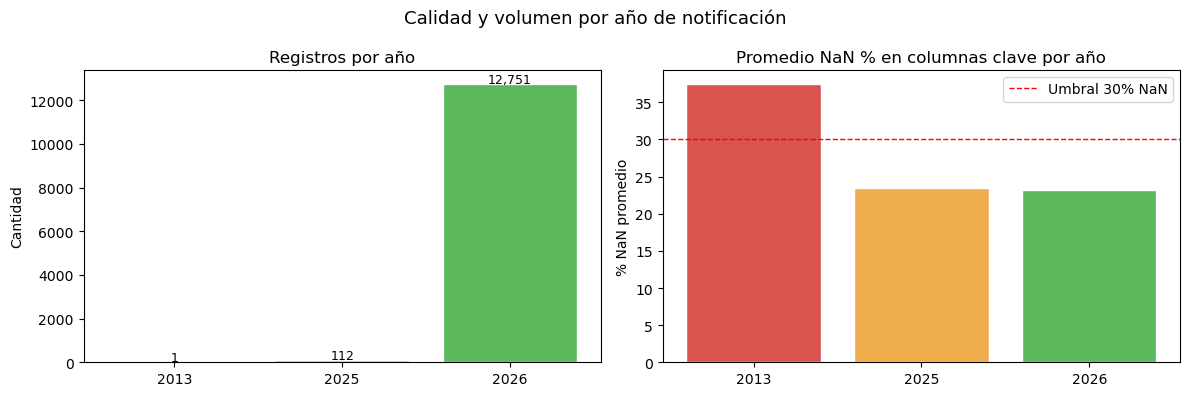


Leyenda colores: 🔴 < 100 registros (descartar)  🟡 < 500 (parcial)  🟢 >= 500 (confiable)


In [15]:

# Visualización: volumen + NaN promedio por año
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

years = [int(y) for y in year_stats]
counts = [year_stats[y]['n'] for y in year_stats]
nulls  = [year_stats[y]['avg_null'] for y in year_stats]

bar_colors = ['#d9534f' if c < 100 else '#f0ad4e' if c < 500 else '#5cb85c' for c in counts]

axes[0].bar([str(y) for y in years], counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Registros por año', fontsize=12)
axes[0].set_ylabel('Cantidad')
for i, (y, n) in enumerate(zip(years, counts)):
    axes[0].text(i, n + 50, f'{n:,}', ha='center', fontsize=9)

axes[1].bar([str(y) for y in years], nulls, color=bar_colors, edgecolor='white')
axes[1].axhline(30, color='red', linestyle='--', linewidth=1, label='Umbral 30% NaN')
axes[1].set_title('Promedio NaN % en columnas clave por año', fontsize=12)
axes[1].set_ylabel('% NaN promedio')
axes[1].legend()

plt.suptitle('Calidad y volumen por año de notificación', fontsize=13)
plt.tight_layout()
plt.show()

print()
print('Leyenda colores: 🔴 < 100 registros (descartar)  🟡 < 500 (parcial)  🟢 >= 500 (confiable)')


## 1d. Filtro de año — conservar solo datos con volumen suficiente

In [16]:

# Decisión de filtro:
# - 2013: 1 registro → error de ingreso de datos, se descarta
# - 2025: 112 registros → insuficiente para análisis estadístico, se documenta como hallazgo
# - 2026: 12,751 registros → el dataset operacional real
#
# Umbral mínimo de registros por año para incluirlo en el análisis
MIN_REGISTROS_POR_YEAR = 500

años_validos = [y for y, s in year_stats.items() if s['n'] >= MIN_REGISTROS_POR_YEAR]
años_descartados = {y: s for y, s in year_stats.items() if s['n'] < MIN_REGISTROS_POR_YEAR}

print('Años descartados por volumen insuficiente:')
for y, s in años_descartados.items():
    print(f'  {int(y)}: {s["n"]} registros ({s["pct_total"]:.2f}% del total) — excluido del análisis')

print()
print(f'Años conservados: {[int(y) for y in años_validos]}')

df_filtered = df[df['_year'].isin(años_validos)].copy()

print()
print(f'Dataset original:  {len(df):,} filas')
print(f'Dataset filtrado:  {len(df_filtered):,} filas')
print(f'Registros excluidos: {len(df) - len(df_filtered):,} ({(len(df) - len(df_filtered)) / len(df) * 100:.2f}%)')

# df_filtered es el dataset limpio que usarán los siguientes notebooks
# Nota: este filtro también se aplica en 02_tutelas_quality.ipynb


Años descartados por volumen insuficiente:
  2013: 1 registros (0.01% del total) — excluido del análisis
  2025: 112 registros (0.86% del total) — excluido del análisis

Años conservados: [2026]

Dataset original:  12,952 filas
Dataset filtrado:  12,751 filas
Registros excluidos: 201 (1.55%)


## 2. Fechas — período cubierto y coherencia temporal

In [19]:
date_cols = [
    'Fecha de creación',
    'Fecha y hora notificación tutela',
    'Fecha Vencimiento Admision',
    'Fecha_Asignacion_Concepto',
    'Fecha Limite Concepto Admisión',
    'Fecha finalización concepto',
    'Fecha y hora de Contestación',
    'Fecha y hora notificación 1ra Instancia',
    'Fecha vencimiento fallo 1ra Instancia',
    'Fecha y hora Notificación 2da Instancia',
    'Fecha vencimiento fallo 2da Instancia',
    'Fecha y hora fallo Corte Constitucional',
    'Fecha vencimiento fallo corte',
]

for col in date_cols:
    df_filtered[col] = pd.to_datetime(df_filtered[col], errors='coerce')

# Rango de fechas de notificación (fecha de ingreso real de la tutela)
print('Período cubierto (notificación tutela):')
print(f'  Desde: {df_filtered["Fecha y hora notificación tutela"].min()}')
print(f'  Hasta: {df_filtered["Fecha y hora notificación tutela"].max()}')
print(f'  Nulos: {df_filtered["Fecha y hora notificación tutela"].isna().sum()}')


Período cubierto (notificación tutela):
  Desde: 2026-01-02 07:30:00
  Hasta: 2026-04-07 11:06:00
  Nulos: 0


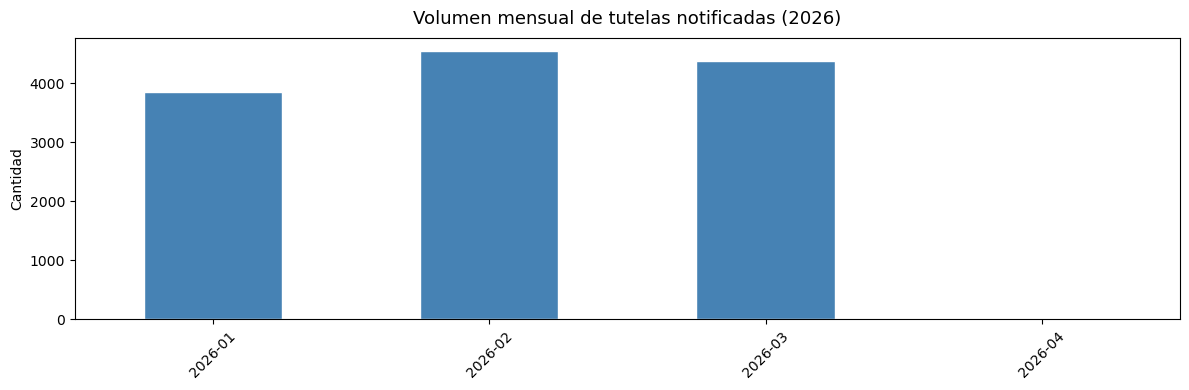

In [20]:
# Volumen mensual de tutelas (solo 2026 — dataset filtrado)
df_filtered['mes_notificacion'] = df_filtered['Fecha y hora notificación tutela'].dt.to_period('M')
vol_mensual = df_filtered['mes_notificacion'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
vol_mensual.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Volumen mensual de tutelas notificadas (2026)', fontsize=13, pad=10)
ax.set_xlabel('')
ax.set_ylabel('Cantidad')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


### Investigación: ¿por qué el gráfico muestra casi todo en 2026?

In [21]:
# Confirmación: todos los registros son de 2026 después del filtro
df_filtered['año_notif'] = df_filtered['Fecha y hora notificación tutela'].dt.year
print('Distribución por año de notificación (df_filtered):')
print(df_filtered['año_notif'].value_counts(dropna=False).sort_index().to_string())
print(f'\nTotal con fecha válida : {df_filtered["año_notif"].notna().sum():,}')
print(f'Total sin fecha (NaT)  : {df_filtered["año_notif"].isna().sum():,}')


Distribución por año de notificación (df_filtered):
año_notif
2026    12751

Total con fecha válida : 12,751
Total sin fecha (NaT)  : 0


In [22]:
# Verificar que no quedan fechas atípicas en el dataset filtrado
outliers = df_filtered[df_filtered['año_notif'].notna() & (df_filtered['año_notif'] != 2026)].copy()
print(f'Registros con año de notificación distinto a 2026 en df_filtered: {len(outliers)}')
if len(outliers) == 0:
    print('✓ Dataset limpio — todos los registros son de 2026.')
else:
    print(outliers[['Fecha de creación', 'Fecha y hora notificación tutela', 'Estado del ciclo de vida', 'Regional T']].to_string())


Registros con año de notificación distinto a 2026 en df_filtered: 0
✓ Dataset limpio — todos los registros son de 2026.


In [23]:
# Coherencia: fecha de creación del registro vs. fecha de notificación
df_filtered['año_creacion'] = df_filtered['Fecha de creación'].dt.year
print('Fecha de CREACIÓN del registro — distribución por año:')
print(df_filtered['año_creacion'].value_counts(dropna=False).sort_index().to_string())
print()
print('Fecha de NOTIFICACIÓN — distribución por año:')
print(df_filtered['año_notif'].value_counts(dropna=False).sort_index().to_string())


Fecha de CREACIÓN del registro — distribución por año:
año_creacion
2026    12751

Fecha de NOTIFICACIÓN — distribución por año:
año_notif
2026    12751


In [24]:
# Meses con volumen inusualmente bajo — posibles cierres de mes o inicio de operación
print('Meses con ≤ 5 tutelas en el dataset filtrado:')
pocos = vol_mensual[vol_mensual <= 5]
if len(pocos) == 0:
    print('  Ninguno — todos los meses tienen volumen suficiente.')
else:
    print(pocos.to_string())
    print(f'\nTotal registros en esos meses: {pocos.sum()}')
    meses_raros = pocos.index.astype(str).tolist()
    df_filtered['mes_str'] = df_filtered['mes_notificacion'].astype(str)
    registros_raros = df_filtered[df_filtered['mes_str'].isin(meses_raros)][
        ['Fecha de creación', 'Fecha y hora notificación tutela',
         'Estado del ciclo de vida', 'Regional T', 'Radicado juzgado']
    ]
    print('\nRegistros en meses con bajo volumen:')
    print(registros_raros.to_string())


Meses con ≤ 5 tutelas en el dataset filtrado:
mes_notificacion
2026-04    1
Freq: M

Total registros en esos meses: 1

Registros en meses con bajo volumen:
      Fecha de creación Fecha y hora notificación tutela        Estado del ciclo de vida Regional T Radicado juzgado
332 2026-01-07 11:06:10              2026-04-07 11:06:00  Cumplimiento Fallo 1 Terminado      NORTE        2025-0336


## 3. Campos categóricos clave — valores únicos y distribución

In [25]:
cat_cols = {
    'Estado del ciclo de vida': 'Estado / etapa del proceso',
    'Compañía': 'Compañía (EPS / ARL)',
    'Regional T': 'Regional',
    'Area causal': 'Área causal',
    'Motivo Causal Juridico': 'Motivo causal jurídico',
    'Clasificación fallo 1ra Instancia': 'Fallo 1ra instancia',
    'Clasificación fallo 2da Instancia': 'Fallo 2da instancia',
    'Tipos respuesta': 'Tipo de respuesta',
    'Medida provisional': 'Medida provisional',
    'PBS/NO PBS': 'PBS / No PBS',
}

for col, label in cat_cols.items():
    vc = df_filtered[col].value_counts(dropna=False)
    print(f'── {label} ({col}) ── {len(vc)} valores únicos')
    print(vc.head(10).to_string())
    print()


── Estado / etapa del proceso (Estado del ciclo de vida) ── 17 valores únicos
Estado del ciclo de vida
Fallo Favorable                   5272
fallo 1 cumplido                  2428
Cumplimiento Fallo 1 Terminado    1407
Gestión fallo 1 área              1401
Fallo 2 cumplido                   625
Expediente Anulado                 275
Espera de Fallo                    272
Fallo Primera Instancia            262
Espera Fallo 2                     262
Cumplimiento fallo 2 Terminado     231

── Compañía (EPS / ARL) (Compañía) ── 7 valores únicos
Compañía
EPS                    9940
ARL                    1997
SEGUROS GENERALES       360
SEGUROS DE VIDA         300
IPS SURA                128
AYUDAS DIAGNOSTICAS      25
CONSULTORIA               1

── Regional (Regional T) ── 10 valores únicos
Regional T
ANTIOQUIA                                      6071
NORTE                                          1948
CENTRO                                         1705
OCCIDENTE                       

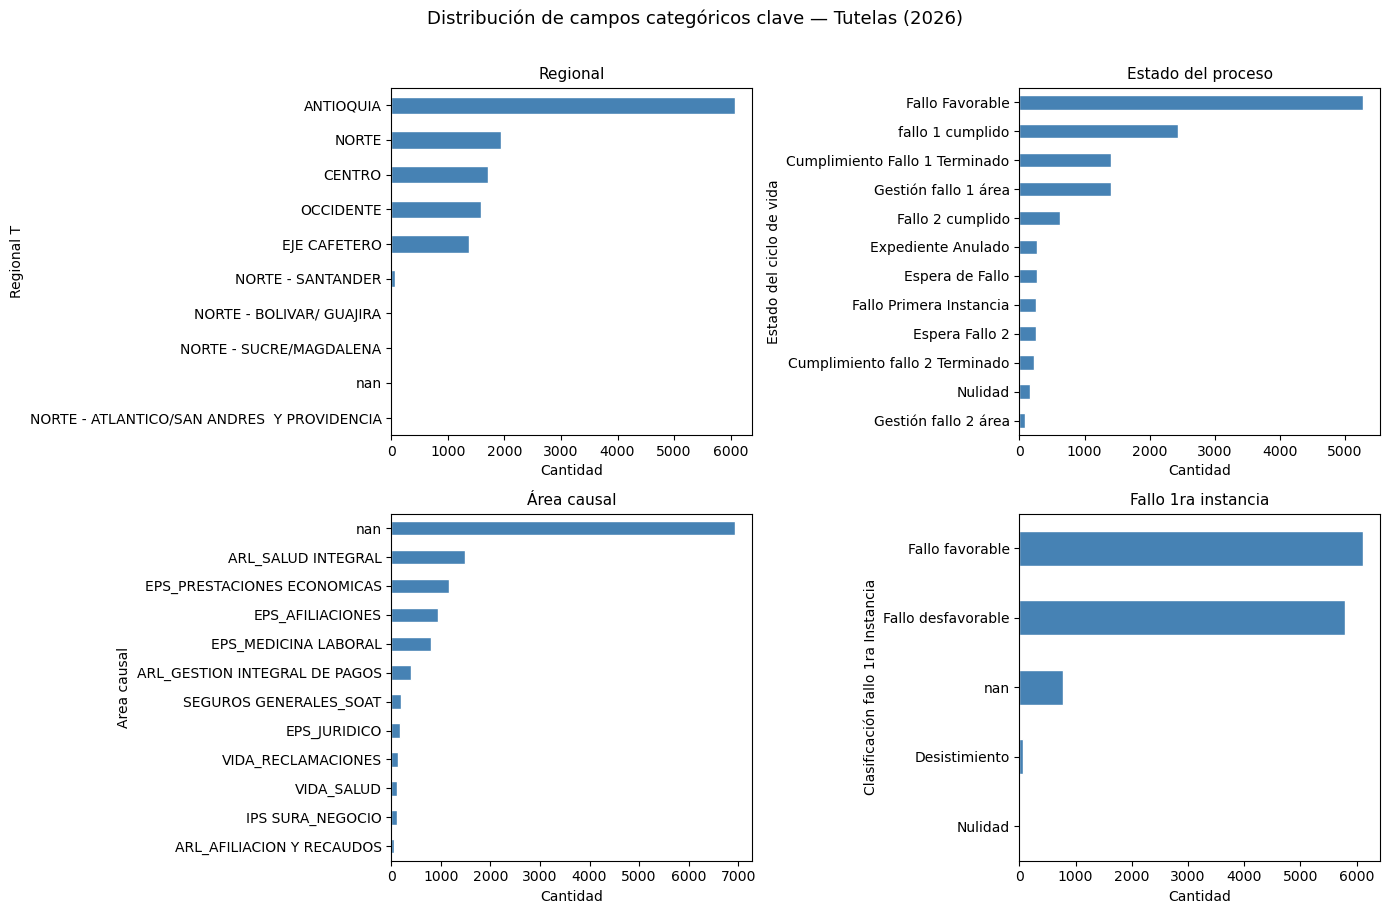

In [26]:
# Distribución visual de los 4 campos más relevantes para el negocio
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_fields = [
    ('Regional T', 'Regional'),
    ('Estado del ciclo de vida', 'Estado del proceso'),
    ('Area causal', 'Área causal'),
    ('Clasificación fallo 1ra Instancia', 'Fallo 1ra instancia'),
]

for ax, (col, title) in zip(axes.flat, plot_fields):
    vc = df_filtered[col].value_counts(dropna=False).head(12)
    vc.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Cantidad')
    ax.invert_yaxis()

plt.suptitle('Distribución de campos categóricos clave — Tutelas (2026)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 4. Nulos por columna — mapa de completitud

In [27]:
nulos = pd.DataFrame({
    'nulos': df_filtered.isnull().sum(),
    'pct_nulo': (df_filtered.isnull().sum() / len(df_filtered) * 100).round(1)
}).sort_values('pct_nulo', ascending=False)

print('Columnas con nulos (ordenado de mayor a menor):')
print(nulos[nulos['nulos'] > 0].to_string())


Columnas con nulos (ordenado de mayor a menor):
                                         nulos  pct_nulo
Fecha y hora fallo Corte Constitucional  12751     100.0
PBS/NO PBS                               12751     100.0
Area causal_4                            12750     100.0
Tutela evitable                          12751     100.0
Motivo Causal Juridico                   12751     100.0
Fecha vencimiento fallo corte            12751     100.0
Prestación sucesiva 1ra instancia        12751     100.0
Area causal_3                            12719      99.7
Odontologia                              12673      99.4
Area causal_2                            11990      94.0
Clasificación fallo 2da Instancia        11152      87.5
Fecha vencimiento fallo 2da Instancia    11076      86.9
Horas para cumplimiento 2da Instancia    11076      86.9
Fecha y hora Notificación 2da Instancia  11076      86.9
Usuario área técnica ARL SALUD           10859      85.2
Tiene Fallo 2da instancia               

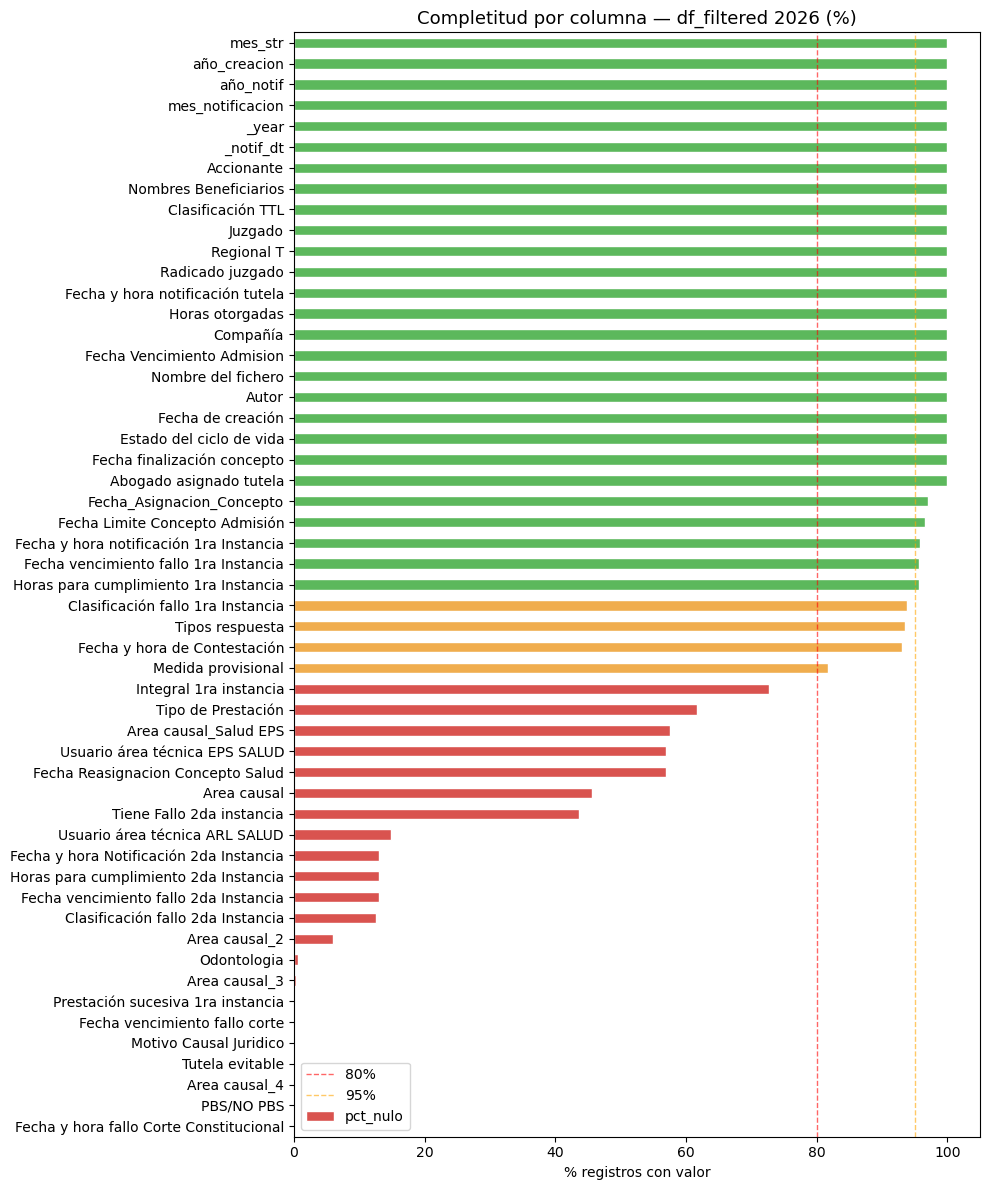

In [28]:
# Visualizar completitud
completitud = (100 - nulos['pct_nulo']).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#d9534f' if v < 80 else '#f0ad4e' if v < 95 else '#5cb85c' for v in completitud]
completitud.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80%')
ax.axvline(95, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='95%')
ax.set_title('Completitud por columna — df_filtered 2026 (%)', fontsize=13)
ax.set_xlabel('% registros con valor')
ax.legend()
plt.tight_layout()
plt.show()


## 4b. Clasificación de nulos — ¿qué se puede eliminar?

Antes de limpiar, separamos los nulos en tres categorías:

| Categoría | Criterio | Acción |
|---|---|---|
| **Vacías** | ≥ 99.9% nulos | Eliminar — no aportan información |
| **Estructurales** | Nulos esperados por el proceso (solo aplican a ciertos estados) | Conservar con contexto |
| **Manejables** | Campos clave con completitud parcial | Conservar + estrategia en nb02 |


In [30]:
# ── GRUPO 1: Columnas completamente vacías (≥99.9% nulos) ──────────────────
cols_vacias = nulos[nulos['pct_nulo'] >= 99.9].index.tolist()

# ── GRUPO 2: Columnas con nulos estructurales (proceso no llega a ese estado) ─
# 2da instancia, Corte Constitucional → solo aplican si el caso llegó a apelación
cols_estructurales = [c for c in df_filtered.columns if '2da' in c or 'corte' in c.lower()]

# ── GRUPO 3: Campos clave con nulos manejables ──────────────────────────────
cols_manejables = nulos[
    (nulos['pct_nulo'] > 0) &
    (~nulos.index.isin(cols_vacias)) &
    (~nulos.index.isin(cols_estructurales))
]

print('═' * 60)
print(f'  GRUPO 1 — Completamente vacías ({len(cols_vacias)} columnas) → ELIMINAR')
print('═' * 60)
for c in cols_vacias:
    print(f'  ✗  {nulos.loc[c, "pct_nulo"]:.1f}%  {c}')

print()
print('═' * 60)
print(f'  GRUPO 2 — Nulos estructurales ({len(cols_estructurales)} columnas) → CONSERVAR')
print('═' * 60)
for c in cols_estructurales:
    pct = nulos.loc[c, 'pct_nulo'] if c in nulos.index else 0.0
    print(f'  ⚙  {pct:.1f}%  {c}')

print()
print('═' * 60)
print(f'  GRUPO 3 — Nulos manejables ({len(cols_manejables)} columnas) → CONSERVAR + tratar en nb02')
print('═' * 60)
print(cols_manejables[['pct_nulo']].to_string())


════════════════════════════════════════════════════════════
  GRUPO 1 — Completamente vacías (7 columnas) → ELIMINAR
════════════════════════════════════════════════════════════
  ✗  100.0%  Fecha y hora fallo Corte Constitucional
  ✗  100.0%  PBS/NO PBS
  ✗  100.0%  Area causal_4
  ✗  100.0%  Tutela evitable
  ✗  100.0%  Motivo Causal Juridico
  ✗  100.0%  Fecha vencimiento fallo corte
  ✗  100.0%  Prestación sucesiva 1ra instancia

════════════════════════════════════════════════════════════
  GRUPO 2 — Nulos estructurales (7 columnas) → CONSERVAR
════════════════════════════════════════════════════════════
  ⚙  56.4%  Tiene Fallo 2da instancia
  ⚙  86.9%  Fecha y hora Notificación 2da Instancia
  ⚙  86.9%  Horas para cumplimiento 2da Instancia
  ⚙  86.9%  Fecha vencimiento fallo 2da Instancia
  ⚙  87.5%  Clasificación fallo 2da Instancia
  ⚙  100.0%  Fecha y hora fallo Corte Constitucional
  ⚙  100.0%  Fecha vencimiento fallo corte

═════════════════════════════════════════════════

In [31]:
# Validación: ¿son realmente estructurales los nulos de 2da instancia?
# Hipótesis: solo los casos que llegan a 2da instancia tienen ese fallo → nulo ESPERADO

tiene_2da = df_filtered['Clasificación fallo 2da Instancia'].notna()

cross = pd.crosstab(
    df_filtered['Estado del ciclo de vida'],
    tiene_2da.map({True: 'Con 2da instancia', False: 'Sin 2da instancia'})
)
cross['% con 2da'] = (cross.get('Con 2da instancia', 0) / cross.sum(axis=1) * 100).round(1)
cross = cross.sort_values('% con 2da', ascending=False)

print('Estado del proceso vs. presencia de fallo de 2da instancia:\n')
print(cross.to_string())

print(f'\nTotal casos con 2da instancia: {tiene_2da.sum():,} ({tiene_2da.mean()*100:.1f}%)')
print(f'Total casos sin 2da instancia: {(~tiene_2da).sum():,} ({(~tiene_2da).mean()*100:.1f}%)')
print()
print('Conclusión: los estados con alta tasa de 2da instancia corresponden a casos de apelación.')
print('Los nulos son ESTRUCTURALES — no es un problema de calidad de dato.')


Estado del proceso vs. presencia de fallo de 2da instancia:

Clasificación fallo 2da Instancia  Con 2da instancia  Sin 2da instancia  % con 2da
Estado del ciclo de vida                                                          
Cumplimiento fallo 2 Terminado                   231                  0      100.0
Gestión fallo 2 área                              85                  0      100.0
Fallo 2 cumplido                                 625                  0      100.0
Fallo segunda instancia                           11                 38       22.4
Fallo Favorable                                  622               4650       11.8
Nulidad                                            4                165        2.4
Fallo Primera Instancia                            2                260        0.8
Gestión fallo 1 área                              10               1391        0.7
Cumplimiento Fallo 1 Terminado                     6               1401        0.4
Espera Fallo 2            

In [32]:
# Investigación: ¿por qué Area causal tiene 54% de nulos?
# Hipótesis: depende del tipo de compañía o del estado del caso

print('── Area causal nula vs. Compañía ──')
cross_cia = pd.crosstab(
    df_filtered['Compañía'],
    df_filtered['Area causal'].isna().map({True: 'Nulo', False: 'Con valor'})
)
cross_cia['% nulo'] = (cross_cia.get('Nulo', 0) / cross_cia.sum(axis=1) * 100).round(1)
print(cross_cia.sort_values('% nulo', ascending=False).to_string())

print()
print('── Area causal nula vs. Estado del ciclo de vida ──')
cross_estado = pd.crosstab(
    df_filtered['Estado del ciclo de vida'],
    df_filtered['Area causal'].isna().map({True: 'Nulo', False: 'Con valor'})
)
cross_estado['% nulo'] = (cross_estado.get('Nulo', 0) / cross_estado.sum(axis=1) * 100).round(1)
print(cross_estado.sort_values('% nulo', ascending=False).head(10).to_string())


── Area causal nula vs. Compañía ──
Area causal          Con valor  Nulo  % nulo
Compañía                                    
EPS                       3125  6815    68.6
SEGUROS DE VIDA            268    32    10.7
SEGUROS GENERALES          322    38    10.6
IPS SURA                   125     3     2.3
ARL                       1956    41     2.1
CONSULTORIA                  1     0     0.0
AYUDAS DIAGNOSTICAS         25     0     0.0

── Area causal nula vs. Estado del ciclo de vida ──
Area causal                     Con valor  Nulo  % nulo
Estado del ciclo de vida                               
Cierre fallo 1                          0     3   100.0
Generar Concepto Tutela                 0     1   100.0
Gestión fallo 1 área                  131  1270    90.6
Cumplimiento Fallo 1 Terminado        155  1252    89.0
Impugnacion                             1     7    87.5
Expediente Anulado                     75   200    72.7
Gestión fallo 2 área                   25    60    70.6
fa

In [33]:
# DECISIÓN FINAL: aplicar eliminación de columnas vacías
# Solo se eliminan las del Grupo 1 (completamente vacías)
# Las demás se conservan en df_filtered y se documentan para nb02

cols_a_eliminar = [c for c in cols_vacias if c in df_filtered.columns]

n_cols_antes = df_filtered.shape[1]
df_filtered.drop(columns=cols_a_eliminar, inplace=True)
n_cols_despues = df_filtered.shape[1]

print(f'Columnas eliminadas ({len(cols_a_eliminar)}):')
for c in cols_a_eliminar:
    print(f'  ✗  {c}')

print()
print(f'Columnas antes:  {n_cols_antes}')
print(f'Columnas ahora:  {n_cols_despues}')
print(f'Filas:           {len(df_filtered):,}  (sin cambio)')

# Recalcular nulos post-limpieza
nulos_final = pd.DataFrame({
    'nulos': df_filtered.isnull().sum(),
    'pct_nulo': (df_filtered.isnull().sum() / len(df_filtered) * 100).round(1)
}).sort_values('pct_nulo', ascending=False)

print(f'\nColumnas restantes con nulos (para tratar en nb02):')
print(nulos_final[nulos_final['nulos'] > 0][['pct_nulo']].to_string())


Columnas eliminadas (7):
  ✗  Fecha y hora fallo Corte Constitucional
  ✗  PBS/NO PBS
  ✗  Area causal_4
  ✗  Tutela evitable
  ✗  Motivo Causal Juridico
  ✗  Fecha vencimiento fallo corte
  ✗  Prestación sucesiva 1ra instancia

Columnas antes:  53
Columnas ahora:  46
Filas:           12,751  (sin cambio)

Columnas restantes con nulos (para tratar en nb02):
                                         pct_nulo
Area causal_3                                99.7
Odontologia                                  99.4
Area causal_2                                94.0
Clasificación fallo 2da Instancia            87.5
Fecha y hora Notificación 2da Instancia      86.9
Fecha vencimiento fallo 2da Instancia        86.9
Horas para cumplimiento 2da Instancia        86.9
Usuario área técnica ARL SALUD               85.2
Tiene Fallo 2da instancia                    56.4
Area causal                                  54.3
Fecha Reasignacion Concepto Salud            43.1
Usuario área técnica EPS SALUD          

## 5. Abogados asignados — carga de trabajo

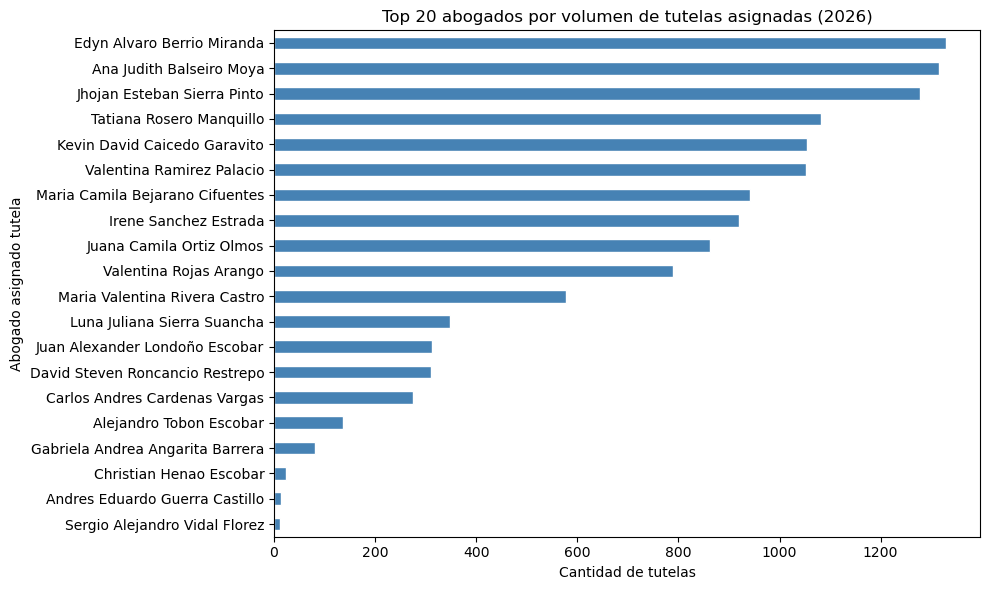

Total abogados distintos: 25


In [29]:
carga = df_filtered['Abogado asignado tutela'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
carga.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 abogados por volumen de tutelas asignadas (2026)', fontsize=12)
ax.set_xlabel('Cantidad de tutelas')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Total abogados distintos: {df_filtered["Abogado asignado tutela"].nunique()}')


## 6. Resumen de exploración

**Anotar aquí los hallazgos de exploración para llevar al documento ejecutivo:**

- Total de registros y período cubierto
- Campos con alta tasa de nulos que pueden limitar el análisis
- Valores extraños o categorías inesperadas
- Preguntas pendientes para el notebook de calidad (02)

> Continuar en `02_tutelas_quality.ipynb`